# Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Instatiate a grid from a DEM raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [2]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

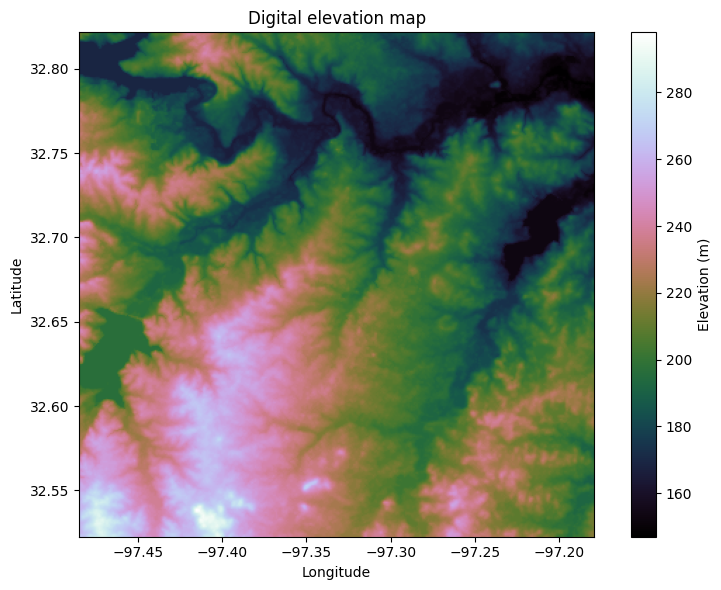

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='cubehelix', zorder=1)
plt.colorbar(label='Elevation (m)')
plt.title('Digital elevation map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('img/conditioned_dem.png', bbox_inches='tight')

# Fill pits and depressions and resolve flats in DEM

In [4]:
grid.resolve_flats('dem', out_name='inflated_dem')

In [7]:
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

# Specify flow direction values

In [8]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Convert DEM to flow direction grid

In [9]:
# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)

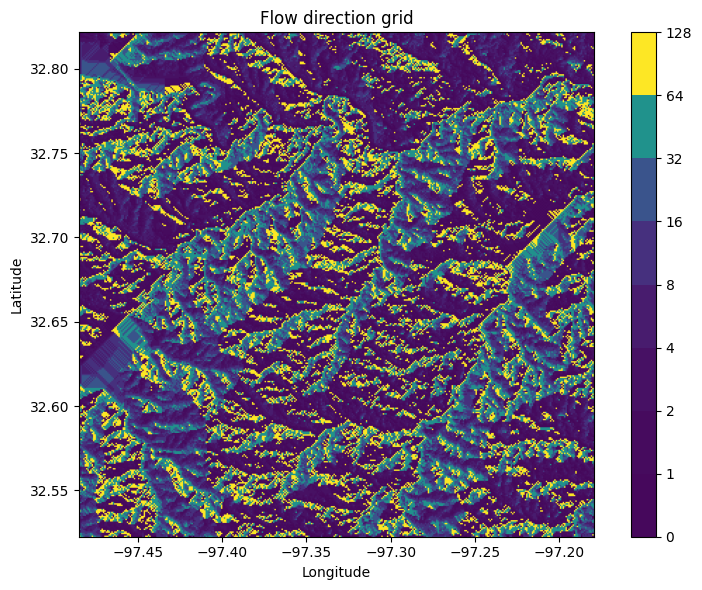

In [10]:
fig = plt.figure(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(fdir, extent=grid.extent, cmap='viridis', zorder=2)
boundaries = ([0] + sorted(list(dirmap)))
plt.colorbar(boundaries= boundaries,
             values=sorted(dirmap))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow direction grid')
plt.tight_layout()
plt.savefig('img/flow_direction.png', bbox_inches='tight')

# Read a flow direction grid from a raster

Data from USGS hydrosheds project: https://hydrosheds.cr.usgs.gov/datadownload.php

In [11]:
fdir = grid.read_ascii('../data/dir.asc', metadata={'dirmap': dirmap})

# Examine grid

In [12]:
fdir

Raster([[  2.,   2.,   4., ...,   4.,   2.,   1.],
        [  1.,   2.,   2., ...,   4.,   4.,   1.],
        [  8.,   1.,   2., ...,   4.,   2.,   2.],
        ...,
        [ 64.,  64.,  32., ...,   8.,   1., 128.],
        [ 64.,  64.,  32., ...,  16.,   2.,   1.],
        [128.,  64.,  64., ...,  16.,   4.,   8.]], shape=(359, 367))

In [13]:
fdir.size

131753

# Examine grid

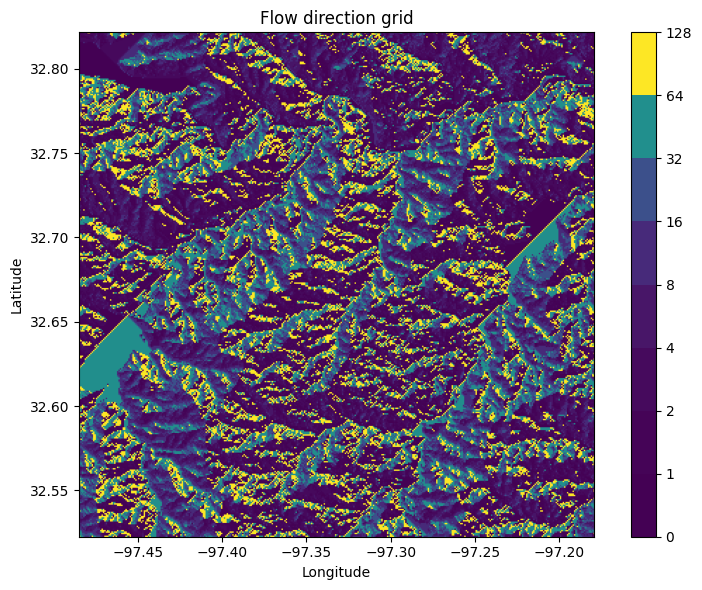

In [14]:
fig = plt.figure(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(fdir, extent=grid.extent, cmap='viridis', zorder=2)
boundaries = ([0] + sorted(list(dirmap)))
plt.colorbar(boundaries= boundaries,
             values=sorted(dirmap))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow direction grid')
plt.grid(zorder=-1)
plt.tight_layout()

# Delineate catchment

In [15]:
# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       xytype='label', algorithm='iterative')

In [25]:
# Clip the bounding box to the catchment
clipped_fdir = grid.view(fdir)
clipped_catch = grid.view(catch)

In [14]:
# Get a view of the catchment
catch = grid.view('catch', nodata=np.nan)

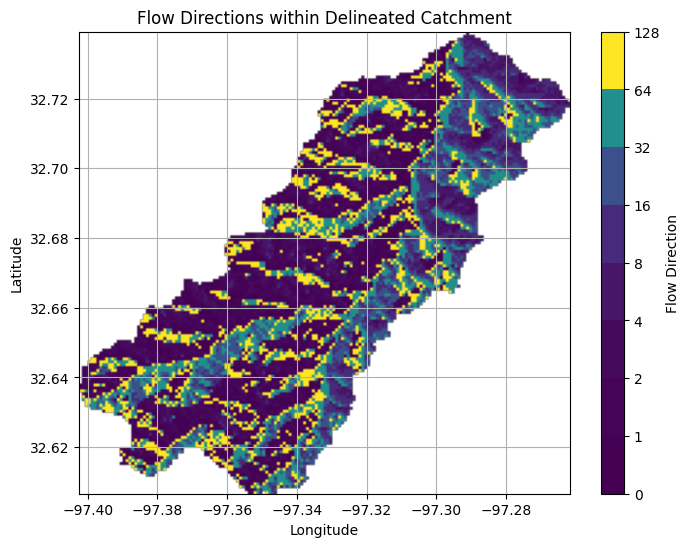

In [28]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

# We mask the fdir so it only shows values where catch > 0
# This gives you the flow direction 'inside' the catchment
fdir_masked = np.where(clipped_catch > 0, clipped_fdir, np.nan)

plt.grid('on', zorder=0)
im = ax.imshow(fdir_masked, extent=grid.extent, zorder=1, cmap='viridis')

# Setup the discrete colorbar for flow directions
boundaries = ([0] + sorted(list(dirmap)))
plt.colorbar(im, ax=ax, boundaries=boundaries, values=sorted(dirmap), label='Flow Direction')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Directions within Delineated Catchment')

plt.savefig('img/catchment_fdir.png', bbox_inches='tight')
plt.show()

# Get flow accumulation

In [29]:
acc = grid.accumulation(fdir=fdir, dirmap=dirmap)

In [30]:
acc_view = grid.view(acc)
catch_view = grid.view(catch)

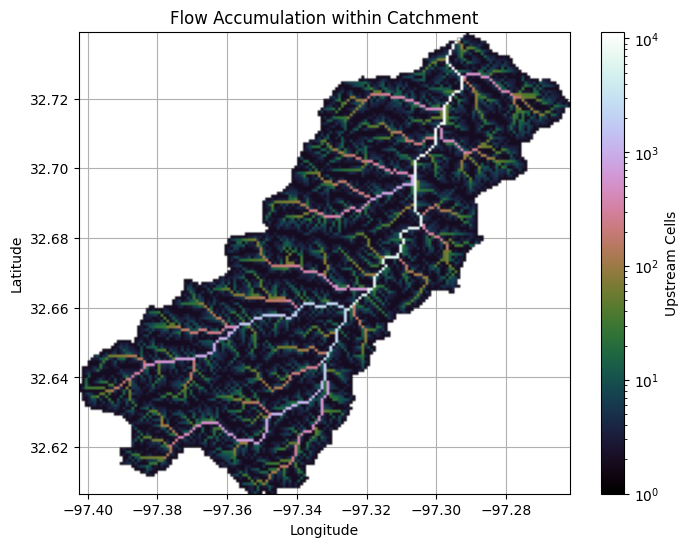

In [31]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)

# Mask the accumulation: only show pixels inside the catchment
# We add +1 because LogNorm cannot handle 0 values (log of 0 is undefined)
acc_masked = np.where(catch_view > 0, acc_view + 1, np.nan)

im = ax.imshow(acc_masked, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc_view.max()))

plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.title('Flow Accumulation within Catchment')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.savefig('img/flow_accumulation.png', bbox_inches='tight')
plt.show()

# Get distances to upstream cells

In [37]:
dist = grid.distance_to_outlet(fdir=fdir, x=x, y=y, dirmap=dirmap, 
                          xytype='label', nodata_out=np.nan)

# views for plotting (Necessary for clipped grids)
dist_view = grid.view(dist)
catch_view = grid.view(catch)

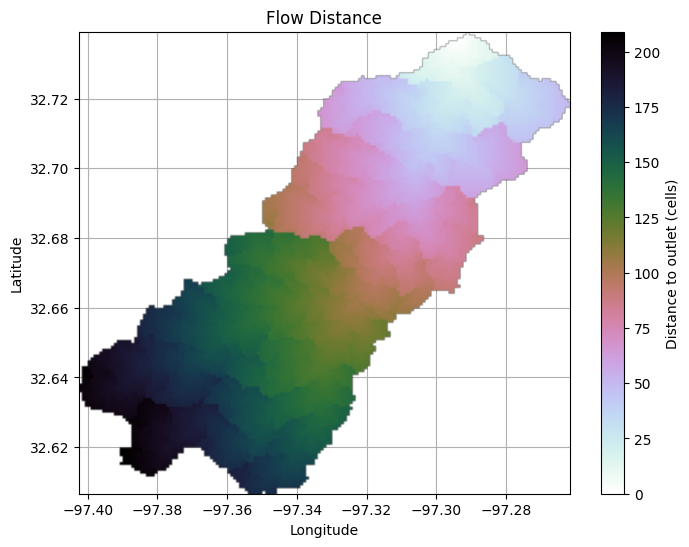

In [38]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)

# Mask the distance: only show values inside the catchment
dist_masked = np.where(catch_view > 0, dist_view, np.nan)

im = ax.imshow(dist_masked, extent=grid.extent, zorder=2,
               cmap='cubehelix_r')

plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance')

plt.savefig('img/flow_distance.png', bbox_inches='tight')
plt.show()